<a href="https://colab.research.google.com/github/mperignon/scratch/blob/main/lilikoi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Colab R

- Google is now supporting a Colab notebook with the R kernel
- We can run R codes directly on Colab
- R Colab Notebook Link: [R Google Colab](https://colab.fan/r)
    - Colab with R kernel
    - With base-R installed
    - Run R codes immediately
    - No need to setup
    - Save a copy in your Drive


## Installing and loading libraries

Switched the order so they first install, then load


In [1]:
##### this installs missing packages. Leave it commented out and uncomment as you run the code and find missing packages

#packages--------------------------
# install.packages("tidyverse", dependencies = TRUE)
# install.packages("table1", dependencies = TRUE)
# install.packages("car", dependencies = TRUE)
# install.packages("dplyr", dependencies = TRUE)
# install.packages("lares", dependencies = TRUE)
# install.packages("boot", dependencies = TRUE)
# install.packages("ggcorrplot", dependencies = TRUE)
# install.packages("rmarkdown", dependencies = TRUE)
# install.packages("ggplot2", dependencies = TRUE)
# install.packages("GGally", dependencies = TRUE)
# install.packages("Hmisc", dependencies = TRUE)
# install.packages("rstatix", dependencies = TRUE)
# install.packages("base", dependencies = TRUE)
# install.packages("truncreg")
# install.packages("interactions")


##### commented most of them out and the code didn't fail, so they can be removed

#libraries---------------------------
library(tidyverse)
# library(table1)
# library(car)
library(dplyr)
# library(lares)
library(boot)
# library(dplyr) # this is already listed above
# library(ggcorrplot)
library(rmarkdown)
library(ggplot2)
# library(table1) # this is already listed above
# library(GGally)
# library(Hmisc)
# library(rstatix)
library(ggplot2) # this is already listed above
# library(interactions)





── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
#import data -------------------------------
setwd("sample_data") ##### sets the working directory (where it finds data) -- changed to the sample data folder
getwd() ##### asks what the working directory is
dir() ##### shows what's inside the working directory

[1] "/content/sample_data"

[1] "anscombe.json"                "california_housing_test.csv" 
[3] "california_housing_train.csv" "mnist_test.csv"              
[5] "mnist_train_small.csv"        "README.md"

In [3]:
#read in data (tidyverse/readr)
maindta <- read.csv("california_housing_train.csv")

#column names----
colnames(maindta) ##### prints the columns
# colnames(cortestdta) ##### this variable hasn't been defined yet, so this fails

[1] "longitude"          "latitude"           "housing_median_age"
[4] "total_rooms"        "total_bedrooms"     "population"        
[7] "households"         "median_income"      "median_house_value"

In [4]:
#remove those under 18---------------
# maindta <- maindta[maindta$age >= 18, ] ##### selects entries where the age variable is >= 18
maindta <- maindta[maindta$total_rooms >= 2, ] ##### selects entries where total_rooms >= 2



In [6]:
##### creates a copy of the data, keeping only columns that are numeric
#correlation test for 2024 crying screaming throwing up--------------
#create new dataset
cortestdta <- maindta %>%
  select_if(is.numeric)

In [24]:
##### drops (select with negative) columns from cortestdta (commented out because I'm using the sample data)
#remove some variables from cortestdta
# cortestdta <- cortestdta %>%
#   select( -msi_bpd_1, -msi_bpd_2, -msi_bpd_3, -msi_bpd_4,
#           -msi_bpd_5, -msi_bpd_6, -msi_bpd_7, -msi_bpd_8, -msi_bpd_9, -msi_bpd_10,
#           -gad7item1_0, -gad7item2_0, -gad7item3_0, -gad7item4_0, -gad7item5_0,
#           -gad7item6_0, -gad7item7_0, -gad7item1_1, -gad7item2_1, -gad7item3_1,
#           -gad7item4_1, -gad7item5_1, -gad7item6_1, -gad7item7_1,
#           -qids_severity_0, -qids_sleep_0, -qids_appweight_0, -qids_psychomotor_0,
#           -qids_feeling_sad_0, -qids_concentration_0, -qids_view_myself_0,
#           -qids_thoughts_of_death_suicide_0, -qids_general_interest_0,
#           -qids_energy_level_0, -qids_severity_1, -qids_sleep_1, -qids_appweight_1,
#           -qids_psychomotor_1, -qids_feeling_sad_1, -qids_concentration_1,
#           -qids_view_myself_1, -qids_thoughts_of_death_suicide_1,
#           -qids_general_interest_1, -qids_energy_level_1, -pcl5_involvement,
#           -pcl5_01, -pcl5_02, -pcl5_03, -pcl5_04, -pcl5_05, -pcl5_06, -pcl5_07,
#           -pcl5_08, -pcl5_09, -pcl5_10, -pcl5_11, -pcl5_12, -pcl5_13, -pcl5_14,
#           -pcl5_15, -pcl5_16, -pcl5_17, -pcl5_18, -pcl5_19, -pcl5_20)

In [11]:
##### uses a built-in library to create a correlation matrix between all variables in the dataset
# Calculate correlation matrix
cor_matrix <- cor(cortestdta, use = "complete.obs", method = "pearson")


In [12]:
cor_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.00000000,-0.92520828,-0.1142503,0.04701044,0.07180196,0.1016742646,0.059627704,-0.0154849614,-0.04498170
latitude,-0.92520828,1.00000000,0.0164539,-0.03877257,-0.06937292,-0.1112613615,-0.074902297,-0.0803030138,-0.14491672
housing_median_age,-0.11425031,0.01645390,1.0000000,-0.36098417,-0.32043408,-0.2958898054,-0.302754191,-0.1159316246,0.10675771
total_rooms,0.04701044,-0.03877257,-0.3609842,1.00000000,0.92840299,0.8601703408,0.919018298,0.1953828074,0.13099147
total_bedrooms,0.07180196,-0.06937292,-0.3204341,0.92840299,1.00000000,0.8811685744,0.980920092,-0.0134946823,0.04578305
population,0.10167426,-0.11126136,-0.2958898,0.86017034,0.88116857,1.0000000000,0.909246530,-0.0006376291,-0.02785006
households,0.05962770,-0.07490230,-0.3027542,0.91901830,0.98092009,0.9092465299,1.000000000,0.0076437162,0.06103063
median_income,-0.01548496,-0.08030301,-0.1159316,0.19538281,-0.01349468,-0.0006376291,0.007643716,1.0000000000,0.69187060
median_house_value,-0.04498170,-0.14491672,0.1067577,0.13099147,0.04578305,-0.0278500611,0.061030634,0.6918706038,1.00000000


In [5]:
##### this is a function to calculate p values and format how they are displayed
##### moved here from higher up

#p-value code for table-----------------------------------------
#Create function to generate p-values (from https://cran.r-project.org/web/packages/table1/vignettes/table1-examples.html)
pvalue <- function(x, ...) {
  # Construct vectors of data y, and groups (strata) g
  y <- unlist(x)
  g <- factor(rep(1:length(x), times=sapply(x, length)))
  if (is.numeric(y)) {
    # For numeric variables, perform a standard 2-sample t-test
    p <- t.test(y ~ g)$p.value
  } else {
    # For categorical variables, perform a chi-squared test of independence
    p <- chisq.test(table(y, g))$p.value
  }
  # Format the p-value, using an HTML entity for the less-than sign.
  # The initial empty string places the output on the line below the variable label.
  c("", sub("<", "&lt;", format.pval(p, digits=3, eps=0.001)))
}

In [17]:
# Calculate p-values

##### creates a matrix (same size as the cortestdta) filled with NA
##### sets the rows and columns to have the same names as cortestdta
p_values <- matrix(NA, ncol = ncol(cortestdta), nrow = ncol(cortestdta))
colnames(p_values) <- rownames(p_values) <- colnames(cortestdta)

##### steps through columns and rows and calculates the p_value (using the function above)
##### writes the p_value in two spots in the matrix (so it's symmetric)
for (i in 1:ncol(cortestdta)) {
  for (j in i:ncol(cortestdta)) {
    if (i != j) { ##### if it's not on the diagonal (same row and column names)
      test <- cor.test(cortestdta[[i]], cortestdta[[j]], method = "pearson")
      p_values[i, j] <-  p_values[j, i] <- test$p.value
    }
  }
}

In [18]:
p_values

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,NA,0.000000e+00,1.697240e-50,8.658974e-10,7.033909e-21,2.639459e-40,7.203709e-15,4.349091e-02,4.425907e-09
latitude,0.000000e+00,NA,3.192775e-02,4.262275e-07,1.361096e-19,5.769413e-48,1.384563e-22,9.975747e-26,1.920028e-80
housing_median_age,1.697240e-50,3.192775e-02,NA,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.967605e-52,2.797067e-44
total_rooms,8.658974e-10,4.262275e-07,0.000000e+00,NA,0.000000e+00,0.000000e+00,0.000000e+00,6.772899e-146,6.084100e-66
total_bedrooms,7.033909e-21,1.361096e-19,0.000000e+00,0.000000e+00,NA,0.000000e+00,0.000000e+00,7.850246e-02,2.342589e-09
population,2.639459e-40,5.769413e-48,0.000000e+00,0.000000e+00,0.000000e+00,NA,0.000000e+00,9.337477e-01,2.816246e-04
households,7.203709e-15,1.384563e-22,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NA,3.189782e-01,1.662151e-15
median_income,4.349091e-02,9.975747e-26,5.967605e-52,6.772899e-146,7.850246e-02,9.337477e-01,3.189782e-01,NA,0.000000e+00
median_house_value,4.425907e-09,1.920028e-80,2.797067e-44,6.084100e-66,2.342589e-09,2.816246e-04,1.662151e-15,0.000000e+00,NA


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



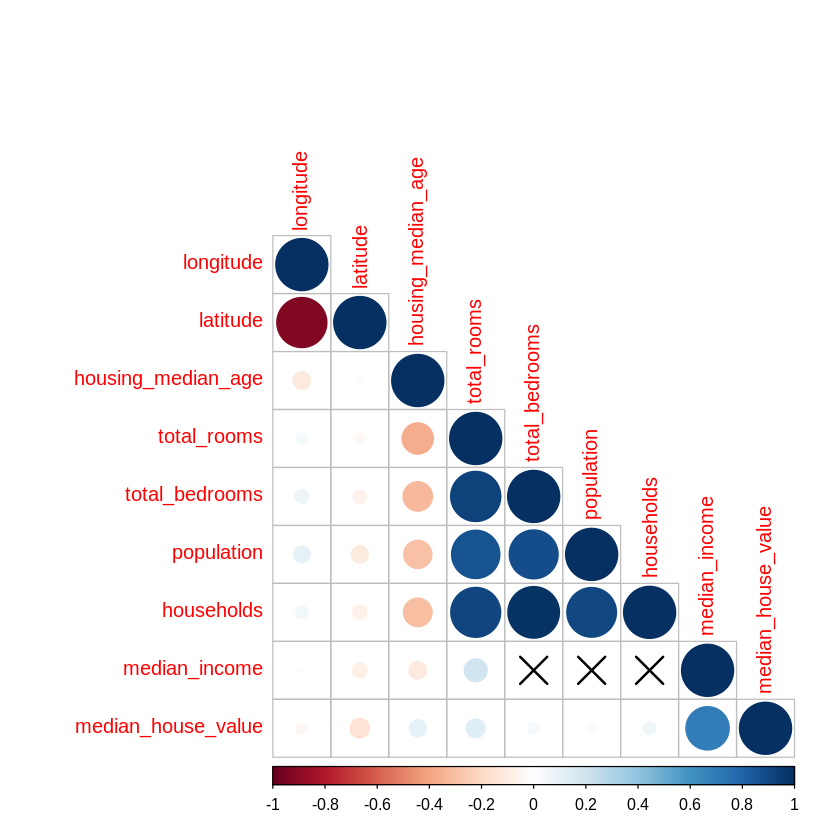

In [23]:
# Visualize correlation
install.packages("corrplot", dependencies = TRUE) ##### installing the library
library(corrplot)

diag(p_values) <- 0 ##### the library corrplot throws an error if the diagonal is NA, so switching to zeros

corrplot(cor_matrix, method = "circle", type = "lower", p.mat = p_values, sig.level = 0.05)

In [28]:
colnames(cortestdta)

[1] "longitude"          "latitude"           "housing_median_age"
[4] "total_rooms"        "total_bedrooms"     "population"        
[7] "households"         "median_income"      "median_house_value"

In [29]:
##### calculates change amounts and percentages for a bunch of variables in cortestdta
##### commented out and write a few for the sample data

##### this is a meaningless comparison! just using it to have an example
cortestdta$val_change <- cortestdta$median_income - cortestdta$median_house_value
cortestdta$val_change_percentage <- (cortestdta$median_income - cortestdta$median_house_value) / cortestdta$median_house_value * 100



#calculate change scores-----------
# cortestdta$rel24_change <- cortestdta$basis24_relationships_1 - cortestdta$basis24_relationships_0
# cortestdta$rel24_change_percentage <- (cortestdta$basis24_relationships_1 - cortestdta$basis24_relationships_0) / cortestdta$basis24_relationships_0 * 100

# cortestdta$gadbin_change <- cortestdta$gad7_binary_1 - cortestdta$gad7_binary_0
# cortestdta$gadbin_change_percentage <- (cortestdta$gad7_binary_1 - cortestdta$gad7_binary_0) / cortestdta$gad7_binary_0 * 100

# cortestdta$gadtot_change <- cortestdta$gad7total_1 - cortestdta$gad7total_0
# cortestdta$gadtot_change_percentage <- (cortestdta$gad7total_1 - cortestdta$gad7total_0) / cortestdta$gad7total_0 * 100

# cortestdta$qidsuic_change <- cortestdta$qids_suicidality_1 - cortestdta$qids_suicidality_0
# cortestdta$qidsuic_change_percentage <- (cortestdta$qids_suicidality_1 - cortestdta$qids_suicidality_0) / cortestdta$qids_suicidality_0 * 100

# cortestdta$suic24_change <- cortestdta$basis24_suicidality_1 - cortestdta$basis24_suicidality_0
# cortestdta$suic24_change_percentage <- (cortestdta$basis24_suicidality_1 - cortestdta$basis24_suicidality_0) / cortestdta$basis24_suicidality_0 * 100

# cortestdta$sib_change <- cortestdta$basis24_sib_1 - cortestdta$basis24_sib_0
# cortestdta$sib_change_percentage <- (cortestdta$basis24_sib_1 - cortestdta$basis24_sib_0) / cortestdta$basis24_sib_0 * 100

# cortestdta$qid_change <- cortestdta$qidstotal_1 - cortestdta$qidstotal_0
# cortestdta$qid_change_percentage <- (cortestdta$qidstotal_1 - cortestdta$qidstotal_0) / cortestdta$qidstotal_0 * 100

# cortestdta$dep24_change <- cortestdta$basis24_depress_1 - cortestdta$basis24_depress_0
# cortestdta$dep24_change_percentage <- (cortestdta$basis24_depress_1 - cortestdta$basis24_depress_0) / cortestdta$basis24_depress_0 * 100

# cortestdta$psy_change <- cortestdta$basis24_psychosis_1 - cortestdta$basis24_psychosis_0
# cortestdta$psy_change_percentage <- (cortestdta$basis24_psychosis_1 - cortestdta$basis24_psychosis_0) / cortestdta$basis24_psychosis_0 * 100

# cortestdta$sub24_change <- cortestdta$basis24_substance_1 - cortestdta$basis24_substance_0
# cortestdta$sub24_change_percentage <- (cortestdta$basis24_substance_1 - cortestdta$basis24_substance_0) / cortestdta$basis24_substance_0 * 100

# cortestdta$emo24_change <- cortestdta$basis24_emotional_1 - cortestdta$basis24_emotional_0
# cortestdta$emo24_change_percentage <- (cortestdta$basis24_emotional_1 - cortestdta$basis24_emotional_0) / cortestdta$basis24_emotional_0 * 100

# cortestdta$shaps_change <- cortestdta$shapstotal_corrected_1 - cortestdta$shapstotal_corrected_0
# cortestdta$shaps_change_percentage <- (cortestdta$shapstotal_corrected_1 - cortestdta$shapstotal_corrected_0) / cortestdta$shapstotal_corrected_0 * 100

In [32]:
##### selects these columns from cortestdta and creates a new dataset
changedta <- cortestdta ##### just as sample

# changedta <- cortestdta[, c("los", "age", "sex", "basis24_demo_gender", "basis24_demo_education",
#                             "basis24_demo_marital","basis24_demo_living","basis24_demo_employment",
#                             "basis24_demo_hospitalized", "basis24_demo_health", "msitotal", "bpd",
#                             "pcl5total", "intrusion_dsm",
#                             "avoidance_dsm", "cogmood_dsm", "arousreact_dsm",  "rel24_change",
#                             "rel24_change_percentage", "gadbin_change",
#                             "gadbin_change_percentage", "gadtot_change", "gadtot_change_percentage",
#                             "qidsuic_change", "qidsuic_change_percentage","suic24_change",
#                             "suic24_change_percentage", "sib_change", "sib_change_percentage", "qid_change",
#                             "qid_change_percentage", "dep24_change", "dep24_change_percentage", "psy_change",
#                             "psy_change_percentage", "sub24_change", "sub24_change_percentage")]

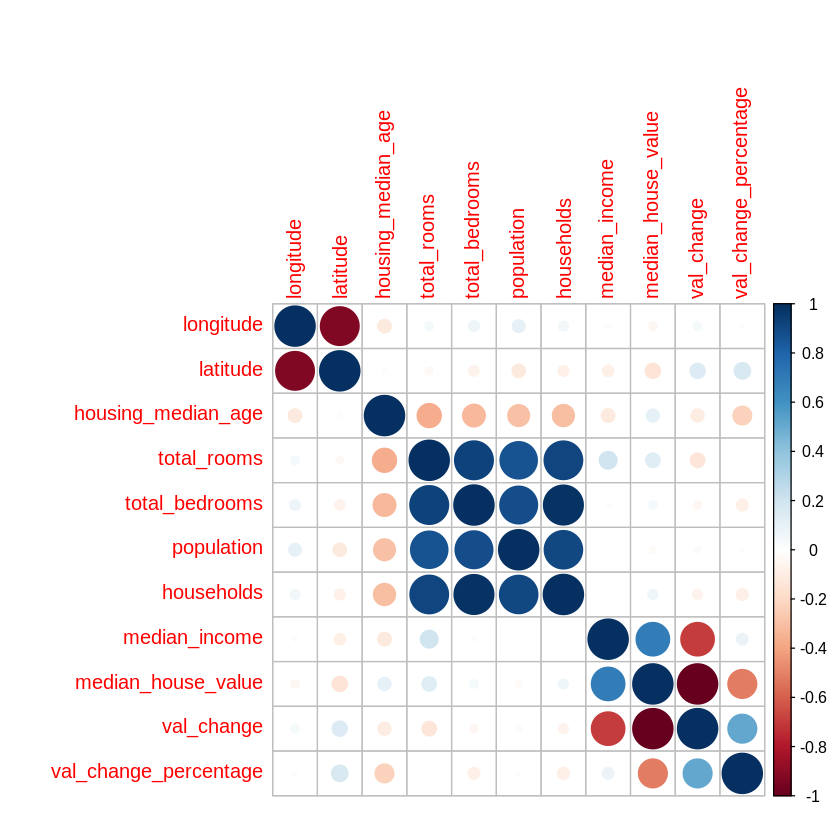

In [33]:
# library(corrplot) ##### don't need to do it again
cor_matrix <- cor(changedta, use = "complete.obs")
corrplot(cor_matrix, method = "circle")

# Did not run anything past this point

In [ ]:
# Select only the change variables for comparison

change_vars <- cortestdta[, c("rel24_change", "gadtot_change", "qidsuic_change",
                              "suic24_change", "sib_change", "qid_change",
                              "dep24_change", "psy_change", "sub24_change", "age",
                              "sex", "basis24_demo_education", "basis24_demo_marital",
                              "basis24_demo_living", "basis24_demo_employment",
                              "basis24_demo_hospitalized", "basis24_demo_health", "msitotal")]

In [ ]:
##### creates a correlation matrix of only the change variables (that it selected above)
# Calculate correlations------------------
cor_matrix <- cor(change_vars, use = "complete.obs")  # Use complete.obs to handle missing data
print(cor_matrix)

##### selects the row 'rel24_change' and displays the values of all columns in the correlation matrix
# If you want to focus only on relationships with rel24_change
cor_with_rel24 <- cor_matrix["rel24_change", ]
print(cor_with_rel24)

In [ ]:
##### this makes a pretty plot

#for poster asthetic
library(reshape2)
cor_data <- data.frame(
  Variable = names(cor_with_rel24),
  Correlation = as.numeric(cor_with_rel24)
)
ggplot(cor_data, aes(x = "rel24_change", y = Variable, fill = Correlation)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
  theme_minimal() +
  labs(title = "Correlation Heatmap", x = "", y = "")

In [ ]:
##### this appears twice in the code

# # Select only the change variables for comparison
# change_vars <- cortestdta[, c("rel24_change", "gadtot_change", "qidsuic_change",
#                               "suic24_change", "sib_change", "qid_change",
#                               "dep24_change", "psy_change", "sub24_change", "age",
#                               "sex", "basis24_demo_education", "basis24_demo_marital",
#                               "basis24_demo_living", "basis24_demo_employment",
#                               "basis24_demo_hospitalized", "basis24_demo_health", "msitotal")]
# # Calculate correlations
# cor_matrix <- cor(change_vars, use = "complete.obs")  # Use complete.obs to handle missing data
# print(cor_matrix)
# # If you want to focus only on relationships with rel24_change
# cor_with_rel24 <- cor_matrix["rel24_change", ]
# print(cor_with_rel24)

In [ ]:
##### First a linear regression to the data
##### predicts rel24_change based on all the other listed variables, using the data in cortestdta
#regression analysis------------
model <- lm(rel24_change ~ gadtot_change + qidsuic_change + suic24_change +
              sib_change + qid_change + dep24_change + psy_change + sub24_change +
            age + sex + basis24_demo_education + basis24_demo_marital +
            basis24_demo_living + basis24_demo_employment +
            basis24_demo_hospitalized + basis24_demo_health,
            data = cortestdta)

##### Displays detailed regression results, including coefficients, R^2 values, p-values, and standard errors
summary(model)

In [ ]:
##### I'm not sure how this works

#moderation analysis after regression analysis
rel24_change ~ dep24_change * msitotal

In [ ]:
##### makes pretty plots

#for poster aesthetic---------------
library(broom) ##### for plotting

# Convert model results to a tidy dataframe
model_results <- tidy(model)
# Filter out the intercept for better visualization
model_results <- model_results[model_results$term != "(Intercept)", ]
# Create the coefficient plot
ggplot(model_results, aes(x = reorder(term, estimate), y = estimate)) +
  geom_point(color = "steelblue", size = 3) +
  geom_errorbar(aes(ymin = estimate - 1.96 * std.error,
                    ymax = estimate + 1.96 * std.error),
                width = 0.2, color = "black") +
  coord_flip() +
  theme_minimal() +
  labs(title = "Regression Coefficients of Interpersonal Relationship Changes",
       x = "Predictor Variables",
       y = "Coefficient Estimate") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red")  # Adds a reference line at zero

S# Scatter plot for rel24_change vs gadtot_change---------
ggplot(cortestdta, aes(x = gadtot_change, y = rel24_change)) +
  geom_point() +
  geom_smooth(method = "lm", color = "blue") +
  labs(title = "Relationship Change vs GAD Total Change",
       x = "GAD Total Change",
       y = "Relationship Change")

In [ ]:
##### calculates a paired t test between rel24_change and psy_change
# T-tests- and visually representing them
t.test(cortestdta$rel24_change, cortestdta$psy_change, paired = TRUE)

library(ggpubr) ##### for plotting

##### creates a matrix that's a certain shape, apparently to make pretty plots
# Convert data into long format for ggplot
long_data <- data.frame(
  Change_Type = rep(c("Interpersonal Relationship Change", "Psychosis Change"), each = nrow(cortestdta)),
  Value = c(cortestdta$rel24_change, cortestdta$psy_change),
  ID = rep(1:nrow(cortestdta), 2)  # For paired connection
)

# Create boxplot with paired lines
ggplot(long_data, aes(x = Change_Type, y = Value)) +
  geom_boxplot(aes(fill = Change_Type), alpha = 0.5) +
  geom_line(aes(group = ID), color = "gray", alpha = 0.2) +
  geom_point(aes(color = Change_Type), position = position_jitter(width = 0.2), alpha = 0.5) +
  labs(title = "Paired Comparison of Relationship and Psychosis Change",
       y = "Change Score",
       x = "Measure") +
  theme_minimal() +
  theme(legend.position = "none")

In [ ]:
##### does the same thing as above, between rel24_change and dep24_change

t.test(cortestdta$rel24_change, cortestdta$dep24_change, paired = TRUE)
long_data <- data.frame(
  Change_Type = rep(c("Interpersonal Relationship Change", "Depression Change"), each = nrow(cortestdta)),
  Value = c(cortestdta$rel24_change, cortestdta$dep24_change),
  ID = rep(1:nrow(cortestdta), 2)  # For paired connection
)

# Create boxplot with paired lines
ggplot(long_data, aes(x = Change_Type, y = Value, fill = Change_Type)) +
  geom_boxplot(alpha = 0.5, outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(aes(color = Change_Type), width = 0.2, alpha = 0.3) +  # Add jittered data points
  stat_summary(fun = mean, geom = "point", shape = 23, size = 3, color = "black", fill = "white") +  # Mean point
  labs(title = "Comparison of Relationship & Depression Change",
       subtitle = "Mean difference: 0.74 (95% CI: 0.67, 0.80), p < 0.001",
       y = "Change Score", x = "Measure") +
  theme_minimal() +
  theme(legend.position = "none")
